analysis -> feat eng -> model -> web app

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:
pd.set_option('display.max.columns', None)

In [129]:
sns.set_style('whitegrid')

In [130]:
df = pd.read_csv("../data/german_credit_data.csv")

In [131]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [132]:
df['Risk'].value_counts

<bound method IndexOpsMixin.value_counts of 0      good
1       bad
2      good
3      good
4       bad
       ... 
995    good
996    good
997    good
998     bad
999    good
Name: Risk, Length: 1000, dtype: str>

In [133]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [134]:
df = df.dropna().reset_index(drop=True)

In [135]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [136]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [137]:
df.drop(columns='Unnamed: 0', inplace=True)


In [138]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


In [139]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [140]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


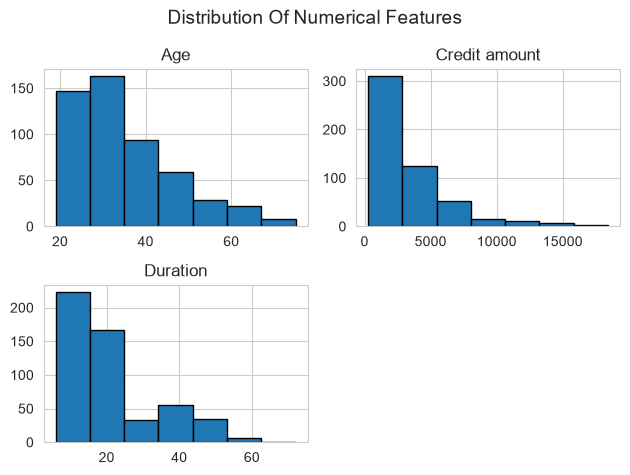

In [141]:
df[['Age', 'Credit amount', 'Duration']].hist(bins=7, edgecolor='black')
plt.suptitle('Distribution Of Numerical Features', fontsize=14)
plt.tight_layout() # Highly recommended to prevent text overlapping!
plt.show()


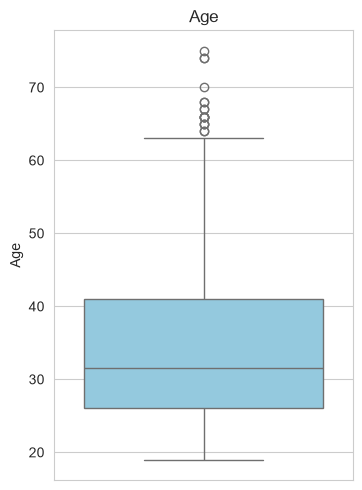

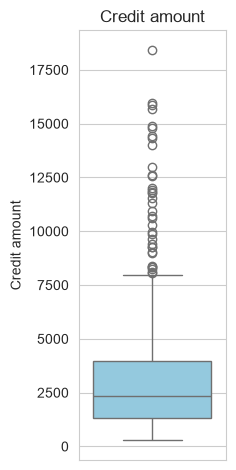

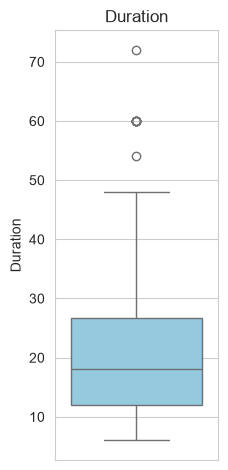

In [142]:
plt.figure(figsize= (10,5))
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
   plt.subplot(1, 3, i + 1)
   sns.boxplot(y = df[col], color= 'skyblue')
   plt.title(col)

   plt.tight_layout()
   plt.show()

In [143]:
df.query('Duration >= 60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [144]:
categorical_cols = ['Sex','Job','Housing','Saving accounts', 'Checking account','Purpose']

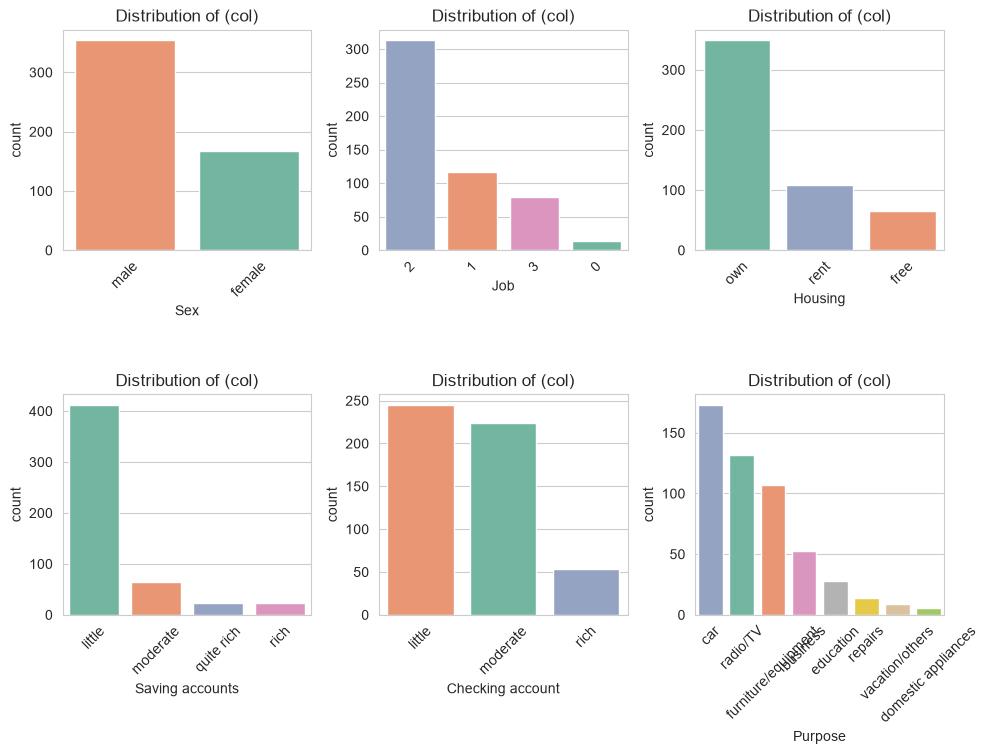

In [145]:
plt.figure(figsize=(10,10))
for i, col in enumerate(categorical_cols):
   plt.subplot(3,3,i+1)
   sns.countplot(data=df, x=col, hue=col, palette='Set2', order=df[col].value_counts().index, legend=False)
   plt.title(f'Distribution of (col)')
   plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [146]:
corr = df[['Age', 'Job', 'Credit amount', 'Duration']].corr()


In [147]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


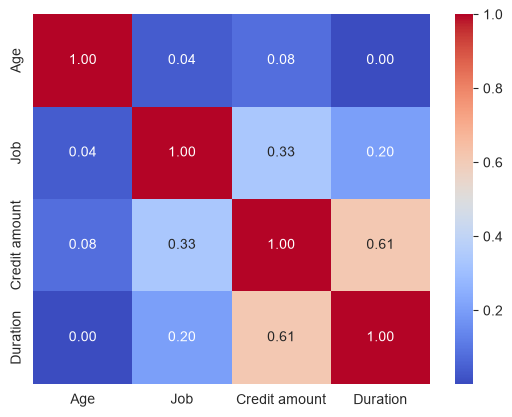

In [148]:
sns.heatmap(corr, annot= True, cmap= 'coolwarm', fmt='.2f')
plt.show()

In [149]:
df.groupby('Job')['Credit amount'].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [150]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [151]:
pd.pivot_table(df, values='Credit amount', index='Housing', columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


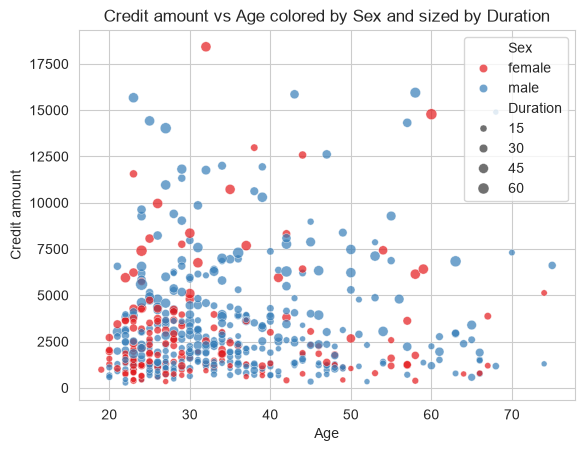

In [152]:
sns.scatterplot(data=df, x= 'Age', y='Credit amount', hue='Sex', size='Duration', alpha=0.7, palette='Set1')
plt.title('Credit amount vs Age colored by Sex and sized by Duration')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2624\2854678460.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data= df, x='Saving accounts', y='Credit amount', palette='Pastel1')


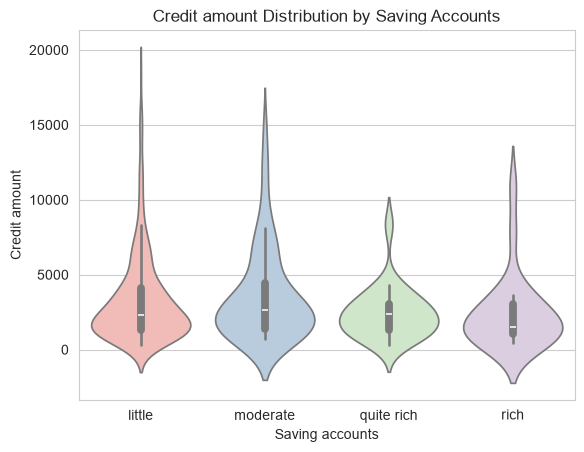

In [153]:
sns.violinplot(data= df, x='Saving accounts', y='Credit amount', palette='Pastel1')
plt.title('Credit amount Distribution by Saving Accounts')
plt.show()

In [154]:
df['Risk'].value_counts(normalize= True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

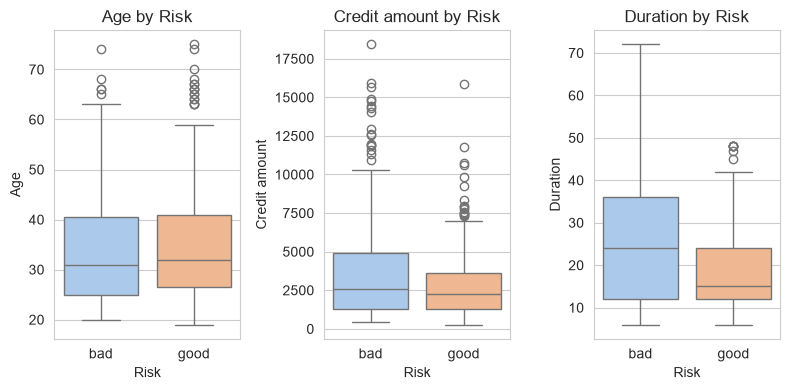

In [155]:
plt.figure(figsize=(8,4))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
   plt.subplot(1, 3, i + 1)
   sns.boxplot(data=df, x='Risk', y=col, hue='Risk', palette='pastel', legend=False)
   plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [156]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

In [157]:
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()


,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


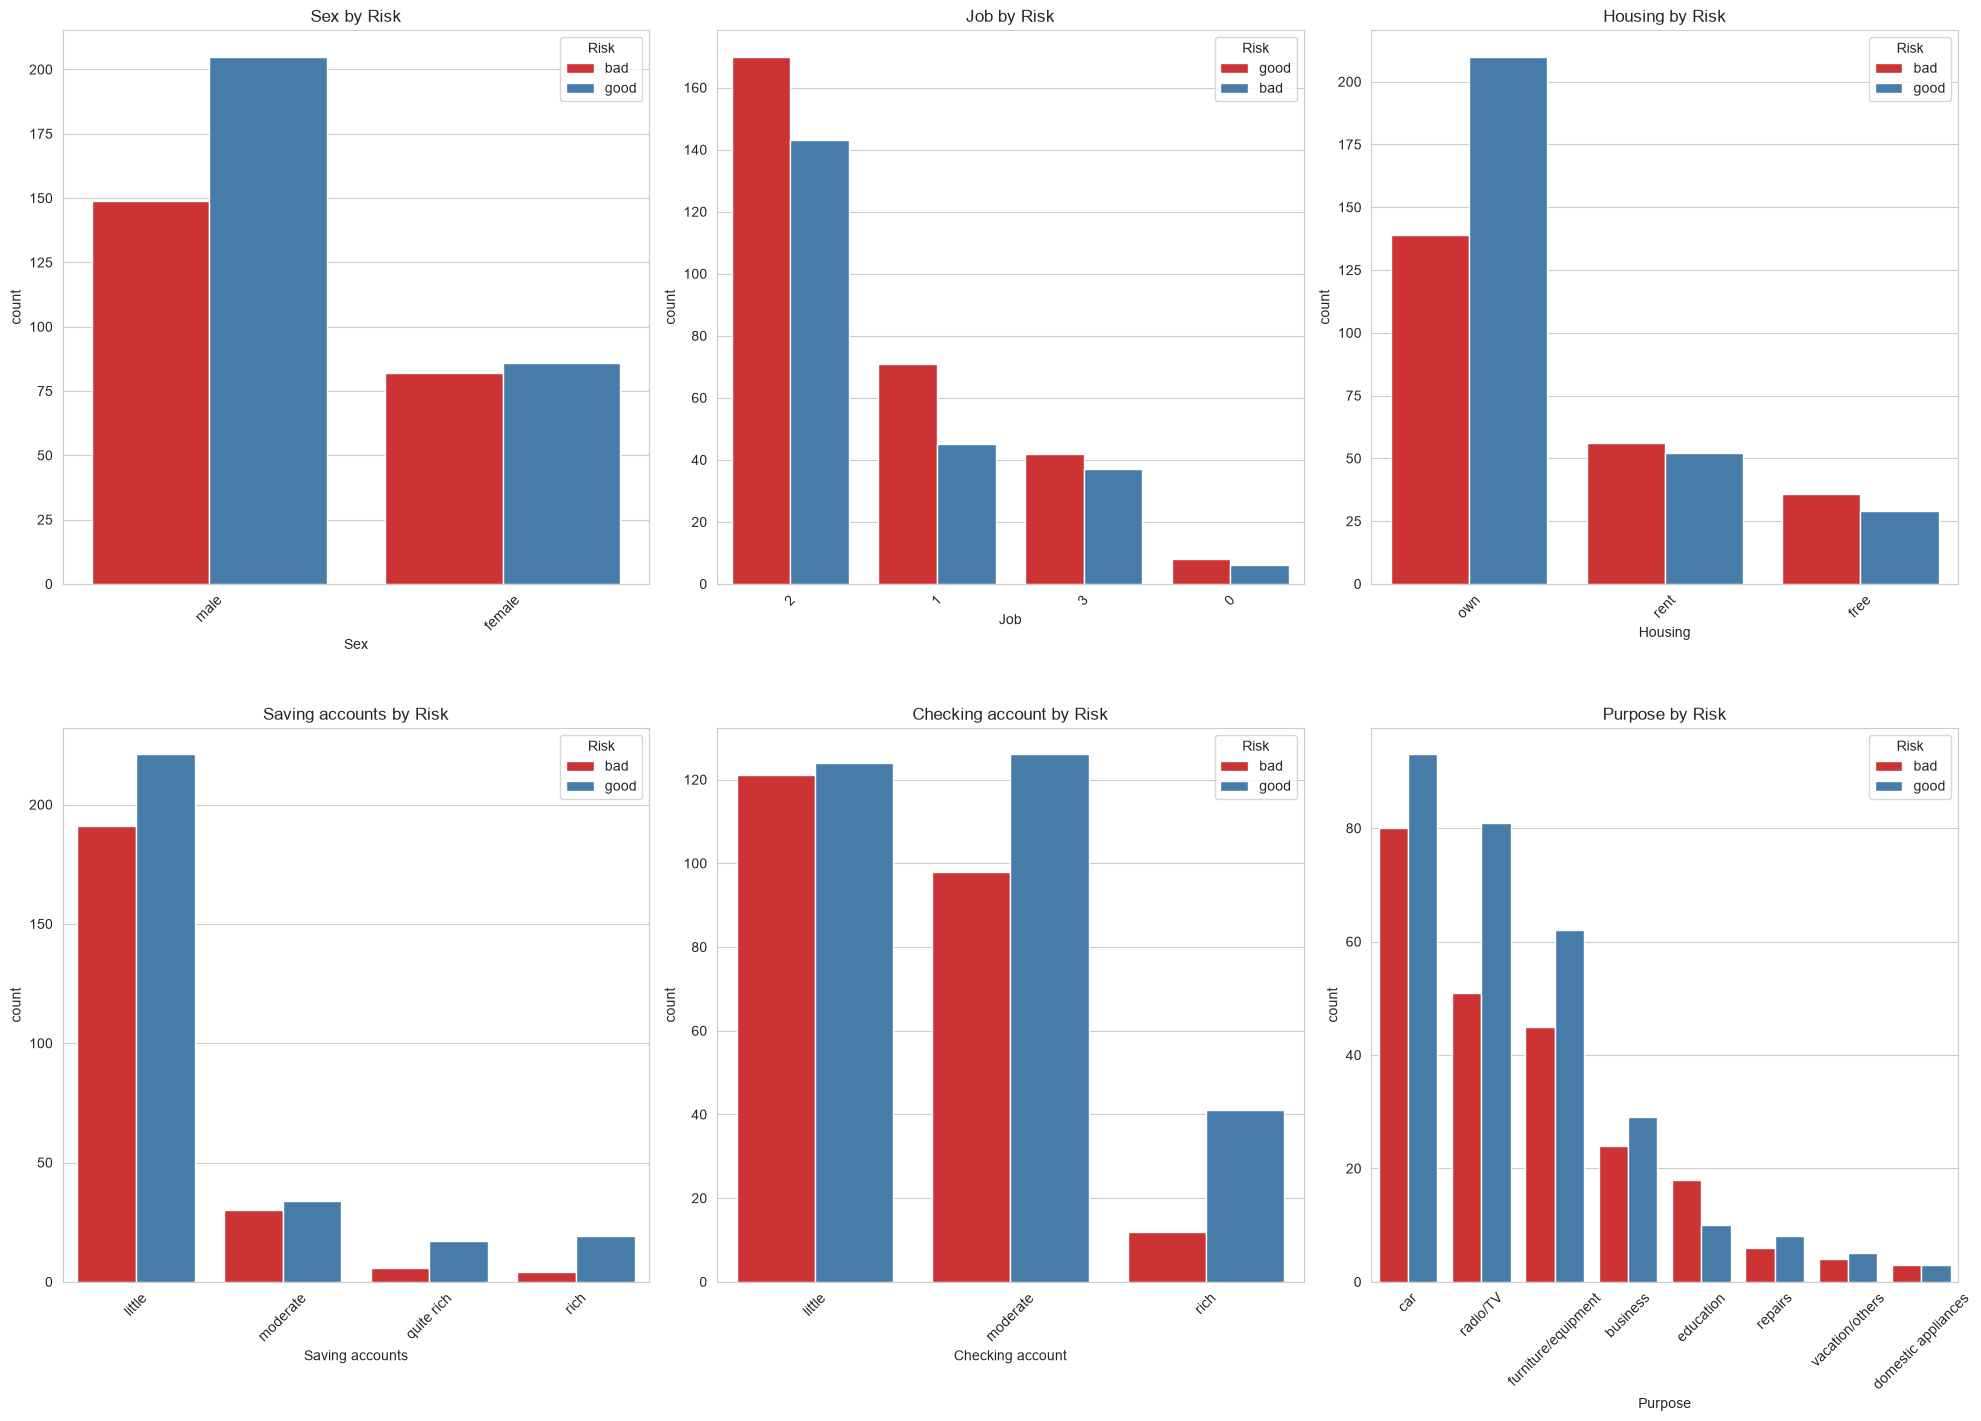

In [158]:
plt.figure(figsize= (20,20))
for i, col in enumerate(categorical_cols):
   plt.subplot(3,3, i+1)
   sns.countplot(data = df, x = col, hue= 'Risk', palette='Set1', order= df[col].value_counts().index)
   plt.title(f"{col} by Risk")
   plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [159]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [160]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration']

In [161]:
target= 'Risk'

In [162]:
df_model = df[features + [target]].copy()

In [163]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [164]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [165]:
cat_cols = df_model.select_dtypes(include='object').columns.drop("Risk")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2624\78657950.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.drop("Risk")


In [166]:
le_dict = {}

In [167]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [168]:
for col in cat_cols:
   le = LabelEncoder()
   df_model[col] = le.fit_transform(df_model[col])
   le_dict[col] = le
   joblib.dump(le, f"{col}_encoder.pkl")

In [169]:
le_target = LabelEncoder()

In [170]:
target

'Risk'

In [171]:
df_model[target] = le_target.fit_transform(df_model[target])

In [172]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [173]:
joblib.dump(le_target, 'target_encoder.pkl')

['target_encoder.pkl']

In [174]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [175]:
from sklearn.model_selection import train_test_split

In [176]:
x = df_model.drop(target, axis=1)

In [177]:
y = df_model[target]

In [178]:
df["Saving accounts"].unique()

<ArrowStringArray>
['little', 'moderate', 'quite rich', 'rich']
Length: 4, dtype: str

In [179]:
df["Checking account"].unique()

<ArrowStringArray>
['moderate', 'little', 'rich']
Length: 3, dtype: str

In [180]:
x

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [181]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [182]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=1)

In [183]:
x_train.shape

(417, 8)

In [184]:
x_test.shape

(105, 8)

In [185]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [186]:
def train_model(model, params_grid, x_train, y_train, x_test, y_test):
   grid = GridSearchCV(model, params_grid, cv = 5, scoring='accuracy', n_jobs=-1)
   grid.fit(x_train, y_train)
   best_model = grid.best_estimator_
   y_pred = best_model.predict(x_test)
   acc = accuracy_score(y_test, y_pred)
   return best_model, acc, grid.best_params_

In [187]:
dt = DecisionTreeClassifier(random_state=1, class_weight='balanced')
dt_params_grid = {
   'max_depth': [3,5,7,10, None],
   'min_samples_split': [7,5,10],
   'min_samples_leaf': [1,2,4]
}

In [188]:
X = df_model.drop(columns=['Risk'])
y = df_model['Risk']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [189]:
best_dt, acc_dt, params_dt = train_model(dt, dt_params_grid, x_train, y_train, x_test, y_test)

In [190]:
print('Decision Tree Accuracy', acc_dt)

Decision Tree Accuracy 0.5904761904761905


In [191]:
print('Best parameter', params_dt)

Best parameter {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 7}


In [192]:
rf = RandomForestClassifier(random_state=1, class_weight='balanced', n_jobs=-1)

In [193]:
rf_param_grid = {
   'n_estimators': [100,200],
   'max_depth': [5, 7, 10, None],
   'min_samples_split': [2,5,10],
   'min_samples_leaf': [1,2,4]
}

In [194]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, x_train, y_train, x_test, y_test)

In [195]:
print('Random Forest Accuracy', acc_rf)

Random Forest Accuracy 0.6666666666666666


In [196]:
print('Params', params_rf)

Params {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [197]:
et = ExtraTreesClassifier(random_state=1, class_weight= 'balanced', n_jobs=-1)

In [198]:
et_param_grid = {
   'n_estimators': [100,200],
   'max_depth': [5, 7, 10, None],
   'min_samples_split': [2,5,10],
   'min_samples_leaf': [1,2,4]
}

In [199]:
best_et, acc_et, params_et = train_model(et, et_param_grid, x_train, y_train, x_test, y_test)

In [200]:
print('Extra trees accuracy', acc_et)

Extra trees accuracy 0.6476190476190476


In [201]:
print('Best_params:', params_et)

Best_params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [202]:
xgb = XGBClassifier(random_state=1, scale_post_weight= (y_train == 0).sum() / (y_train == 1).sum(), use_label_encoder= False, eval_metric= 'logloss')

In [203]:
xgb_param_grid = {
   'n_estimator': [100, 200],
   'max_depth': [3, 5, 7],
   'learning_rate': [0.01, 0.1, 0.2],
   'subsample': [0.7, 1],
   'colsample_bytree': [0.7, 1]
}

In [204]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, x_train, y_train, x_test, y_test)

c:\Dev\Sch project\credit-scoring\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:03:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator", "scale_post_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [205]:
print('XGB accuracy', acc_xgb)

XGB accuracy 0.638095238095238


In [206]:
print('Best params', params_xgb)

Best params {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimator': 100, 'subsample': 1}


In [207]:
best_et.predict(x_test)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1])

In [208]:
joblib.dump(best_et, 'extral_trees_credit_model.pkl')

['extral_trees_credit_model.pkl']

In [209]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [210]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [211]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42)
}

In [212]:
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]

    cv_scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='f1')

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "F1 (Macro)": f1_score(y_test, y_pred, average='macro'),
        "F1 (Weighted)": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "CV F1 (mean ± std)": f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}"
    })

results_df = pd.DataFrame(results).sort_values(by="F1 (Macro)", ascending=False)
results_df

c:\Dev\Sch project\credit-scoring\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\Sch project\credit-scoring\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\Sch project\credit-scoring\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\Sch project\credit-scoring\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was

,Model,Accuracy,Precision,Recall,F1 Score,F1 (Macro),F1 (Weighted),ROC-AUC,CV F1 (mean ± std)
4,XGBoost,0.647619,0.689655,0.677966,0.683761,0.642956,0.648008,0.714075,0.674 ± 0.041
1,Random Forest,0.657143,0.666667,0.779661,0.718750,0.639863,0.649630,0.686072,0.691 ± 0.025
2,Extra Trees,0.647619,0.666667,0.745763,0.704000,0.634353,0.642976,0.682940,0.664 ± 0.011
0,Logistic Regression,0.638095,0.647887,0.779661,0.707692,0.616346,0.627656,0.672808,0.681 ± 0.022
3,SVM,0.619048,0.602151,0.949153,0.736842,0.523593,0.549996,0.545321,0.712 ± 0.046


In [213]:
# Define balanced versions of each model
# XGBoost doesn't have class_weight; it uses scale_pos_weight instead
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

balanced_models = {
    "Logistic Regression (Balanced)": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Random Forest (Balanced)": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Extra Trees (Balanced)": ExtraTreesClassifier(random_state=42, class_weight='balanced'),
    "SVM (Balanced)": SVC(probability=True, random_state=42, class_weight='balanced'),
    "XGBoost (Balanced)": xgb.XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=scale_pos_weight)
}

balanced_results = []

for name, model in balanced_models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]

    cv_scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='f1_macro')

    balanced_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Good)": recall_score(y_test, y_pred),
        "Recall (Bad)": recall_score(y_test, y_pred, pos_label=0),
        "F1 (Macro)": f1_score(y_test, y_pred, average='macro'),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "CV F1 Macro (mean ± std)": f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}"
    })

balanced_results_df = pd.DataFrame(balanced_results).sort_values(by="F1 (Macro)", ascending=False)
balanced_results_df

c:\Dev\Sch project\credit-scoring\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Dev\Sch project\credit-scoring\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\Sch project\credit-scoring\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `p

,Model,Accuracy,Precision,Recall (Good),Recall (Bad),F1 (Macro),ROC-AUC,CV F1 Macro (mean ± std)
4,XGBoost (Balanced),0.657143,0.694915,0.694915,0.608696,0.651805,0.700074,0.630 ± 0.026
1,Random Forest (Balanced),0.657143,0.682540,0.728814,0.565217,0.647914,0.686993,0.618 ± 0.027
2,Extra Trees (Balanced),0.647619,0.671875,0.728814,0.543478,0.636950,0.675755,0.609 ± 0.028
0,Logistic Regression (Balanced),0.609524,0.640625,0.694915,0.500000,0.597701,0.673176,0.628 ± 0.031
3,SVM (Balanced),0.600000,0.602410,0.847458,0.282609,0.543289,0.513633,0.543 ± 0.094


In [214]:
# Build a comparison table: unbalanced vs balanced, per model, on F1(Macro) and Recall(Bad)
comparison_rows = []

model_pairs = [
    ("Logistic Regression", "Logistic Regression (Balanced)"),
    ("Random Forest", "Random Forest (Balanced)"),
    ("Extra Trees", "Extra Trees (Balanced)"),
    ("SVM", "SVM (Balanced)"),
    ("XGBoost", "XGBoost (Balanced)")
]

for original_name, balanced_name in model_pairs:
    orig_row = results_df[results_df["Model"] == original_name].iloc[0]
    bal_row = balanced_results_df[balanced_results_df["Model"] == balanced_name].iloc[0]

    comparison_rows.append({
        "Model": original_name,
        "F1 (Macro) - Before": round(orig_row["F1 (Macro)"], 3),
        "F1 (Macro) - After": round(bal_row["F1 (Macro)"], 3),
        "F1 (Macro) - Change": round(bal_row["F1 (Macro)"] - orig_row["F1 (Macro)"], 3),
        "Recall (Bad) - After": round(bal_row["Recall (Bad)"], 3),
        "ROC-AUC - Before": round(orig_row["ROC-AUC"], 3),
        "ROC-AUC - After": round(bal_row["ROC-AUC"], 3)
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,F1 (Macro) - Before,F1 (Macro) - After,F1 (Macro) - Change,Recall (Bad) - After,ROC-AUC - Before,ROC-AUC - After
0,Logistic Regression,0.616,0.598,-0.019,0.500,0.673,0.673
1,Random Forest,0.640,0.648,0.008,0.565,0.686,0.687
2,Extra Trees,0.634,0.637,0.003,0.543,0.683,0.676
3,SVM,0.524,0.543,0.020,0.283,0.545,0.514
4,XGBoost,0.643,0.652,0.009,0.609,0.714,0.700


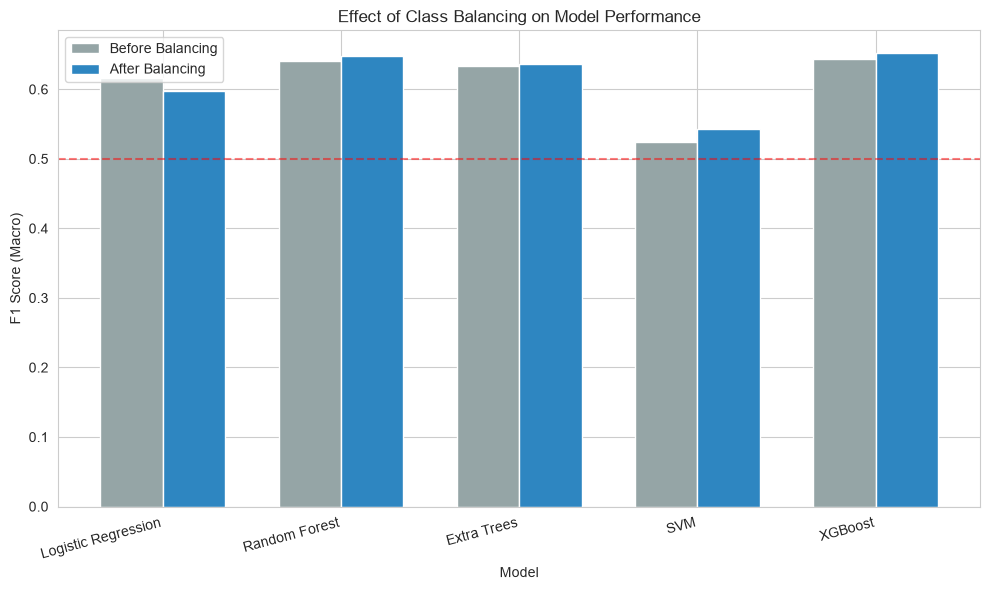

In [215]:
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(comparison_df))
width = 0.35

ax.bar([i - width/2 for i in x], comparison_df["F1 (Macro) - Before"], width, label='Before Balancing', color='#95a5a6')
ax.bar([i + width/2 for i in x], comparison_df["F1 (Macro) - After"], width, label='After Balancing', color='#2E86C1')

ax.set_xlabel('Model')
ax.set_ylabel('F1 Score (Macro)')
ax.set_title('Effect of Class Balancing on Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Model"], rotation=15, ha='right')
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
plt.tight_layout()
plt.show()

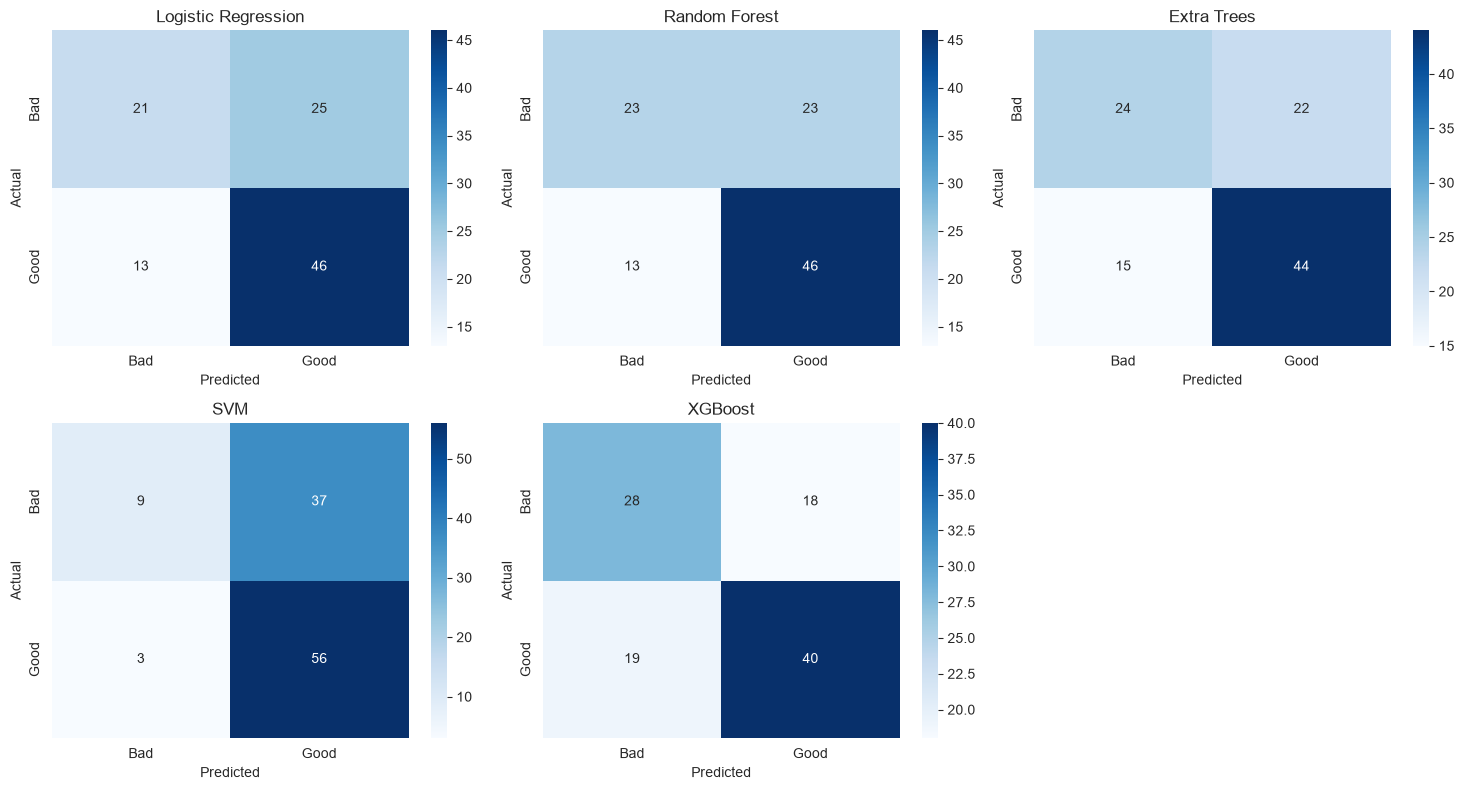

In [216]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Hide any unused subplot
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

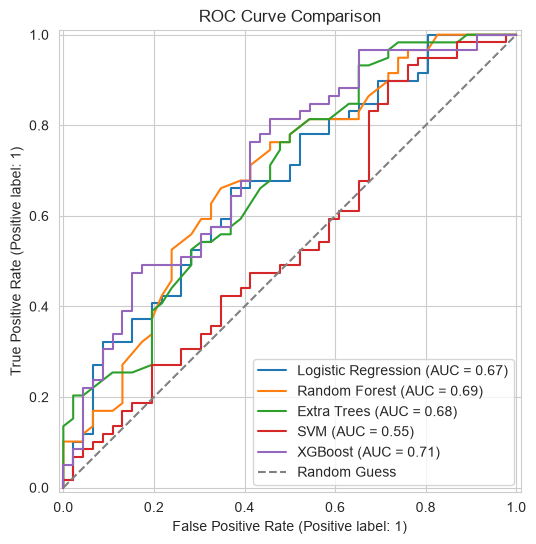

In [217]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax=ax, name=name)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.title("ROC Curve Comparison")
plt.legend(loc='lower right')
plt.show()

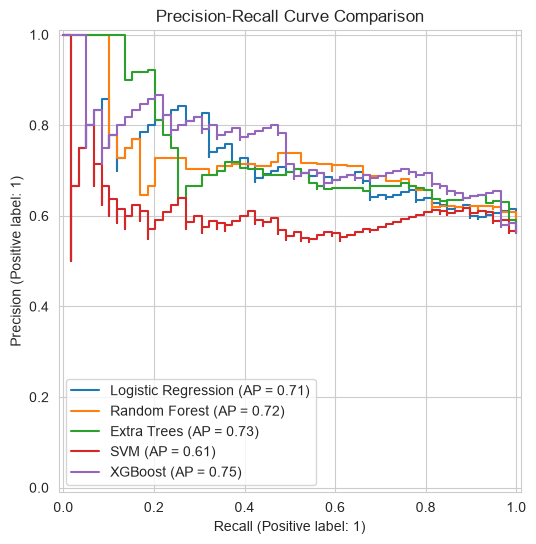

In [218]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, x_test, y_test, ax=ax, name=name)

plt.title("Precision-Recall Curve Comparison")
plt.legend(loc='lower left')
plt.show()

In [219]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Detailed report for: {best_model_name}\n")
print(classification_report(y_test, best_model.predict(x_test), target_names=['Bad', 'Good']))

Detailed report for: XGBoost

              precision    recall  f1-score   support

         Bad       0.60      0.61      0.60        46
        Good       0.69      0.68      0.68        59

    accuracy                           0.65       105
   macro avg       0.64      0.64      0.64       105
weighted avg       0.65      0.65      0.65       105



In [220]:
import joblib

# Retrain balanced XGBoost on the full training set (already done above, but ensuring it's fit)
final_model = balanced_models["XGBoost (Balanced)"]
final_model.fit(x_train, y_train)

# Save the model
joblib.dump(final_model, 'xgboost_balanced_credit_model.pkl')

print("Model saved as xgboost_balanced_credit_model.pkl")
print(f"Feature order expected by model: {list(x_train.columns)}")

Model saved as xgboost_balanced_credit_model.pkl
Feature order expected by model: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration']


In [221]:
# Get predictions from your best model (balanced XGBoost) on the test set
y_pred_final = final_model.predict(x_test)
y_proba_final = final_model.predict_proba(x_test)[:, 1]

# Build an evaluation dataframe that includes the sensitive attribute
# NOTE: Sex is encoded numerically in x_test — check your encoder to confirm which value maps to which label
sex_encoder = encoders["Sex"] if 'encoders' in dir() else joblib.load('Sex_encoder.pkl')
print("Sex encoding:", dict(zip(sex_encoder.classes_, sex_encoder.transform(sex_encoder.classes_))))

fairness_df = pd.DataFrame({
    'Sex_encoded': x_test['Sex'].values,
    'y_true': y_test.values,
    'y_pred': y_pred_final,
    'y_proba': y_proba_final
})

# Map back to readable labels
fairness_df['Sex'] = sex_encoder.inverse_transform(fairness_df['Sex_encoded'])
fairness_df.head()

Sex encoding: {'female': np.int64(0), 'male': np.int64(1)}


,Sex_encoded,y_true,y_pred,y_proba,Sex
0,1,0,0,0.430022,male
1,1,1,1,0.734061,male
2,1,0,0,0.010923,male
3,1,1,0,0.387102,male
4,1,1,0,0.378735,male


In [222]:
from sklearn.metrics import confusion_matrix

def group_metrics(group_df):
    tn, fp, fn, tp = confusion_matrix(group_df['y_true'], group_df['y_pred']).ravel()
    return pd.Series({
        'Count': len(group_df),
        'Approval Rate (Predicted Good)': (group_df['y_pred'] == 1).mean(),
        'Actual Good Rate': (group_df['y_true'] == 1).mean(),
        'Accuracy': (group_df['y_true'] == group_df['y_pred']).mean(),
        'TPR (Recall on Good)': tp / (tp + fn) if (tp + fn) > 0 else None,
        'FPR (Bad predicted as Good)': fp / (fp + tn) if (fp + tn) > 0 else None,
        'TNR (Recall on Bad)': tn / (tn + fp) if (tn + fp) > 0 else None,
        'Avg Predicted Probability': group_df['y_proba'].mean()
    })

fairness_summary = fairness_df.groupby('Sex').apply(group_metrics)
fairness_summary

,Count,Approval Rate (Predicted Good),Actual Good Rate,Accuracy,TPR (Recall on Good),FPR (Bad predicted as Good),TNR (Recall on Bad),Avg Predicted Probability
Sex,,,,,,,,
female,36.0,0.527778,0.583333,0.611111,0.619048,0.400000,0.600000,0.508482
male,69.0,0.579710,0.550725,0.681159,0.736842,0.387097,0.612903,0.554846


In [223]:
male_row = fairness_summary.loc['male']
female_row = fairness_summary.loc['female']

print("=== Fairness Gap Analysis ===\n")

# Demographic Parity: do approval rates differ by group?
dp_diff = male_row['Approval Rate (Predicted Good)'] - female_row['Approval Rate (Predicted Good)']
print(f"Demographic Parity Difference (Male - Female approval rate): {dp_diff:.3f}")
print("  -> Ideally close to 0. Values further from 0 suggest disparate approval rates.\n")

# Equal Opportunity: do True Positive Rates (recall on 'Good') differ?
eo_diff = male_row['TPR (Recall on Good)'] - female_row['TPR (Recall on Good)']
print(f"Equal Opportunity Difference (Male - Female TPR): {eo_diff:.3f}")
print("  -> Measures whether qualified 'Good' applicants are equally likely to be approved regardless of sex.\n")

# False Positive Rate gap: are risky applicants from one group more likely to slip through?
fpr_diff = male_row['FPR (Bad predicted as Good)'] - female_row['FPR (Bad predicted as Good)']
print(f"FPR Difference (Male - Female): {fpr_diff:.3f}")
print("  -> Measures whether 'Bad' risk applicants from one group are more likely to be wrongly approved.\n")

# Disparate impact ratio (80% rule, common legal threshold in US employment law, sometimes referenced in credit too)
di_ratio = female_row['Approval Rate (Predicted Good)'] / male_row['Approval Rate (Predicted Good)']
print(f"Disparate Impact Ratio (Female/Male approval rate): {di_ratio:.3f}")
print("  -> Values below 0.8 are often flagged as potentially discriminatory under the '80% rule'.")

=== Fairness Gap Analysis ===

Demographic Parity Difference (Male - Female approval rate): 0.052
  -> Ideally close to 0. Values further from 0 suggest disparate approval rates.

Equal Opportunity Difference (Male - Female TPR): 0.118
  -> Measures whether qualified 'Good' applicants are equally likely to be approved regardless of sex.

FPR Difference (Male - Female): -0.013
  -> Measures whether 'Bad' risk applicants from one group are more likely to be wrongly approved.

Disparate Impact Ratio (Female/Male approval rate): 0.910
  -> Values below 0.8 are often flagged as potentially discriminatory under the '80% rule'.


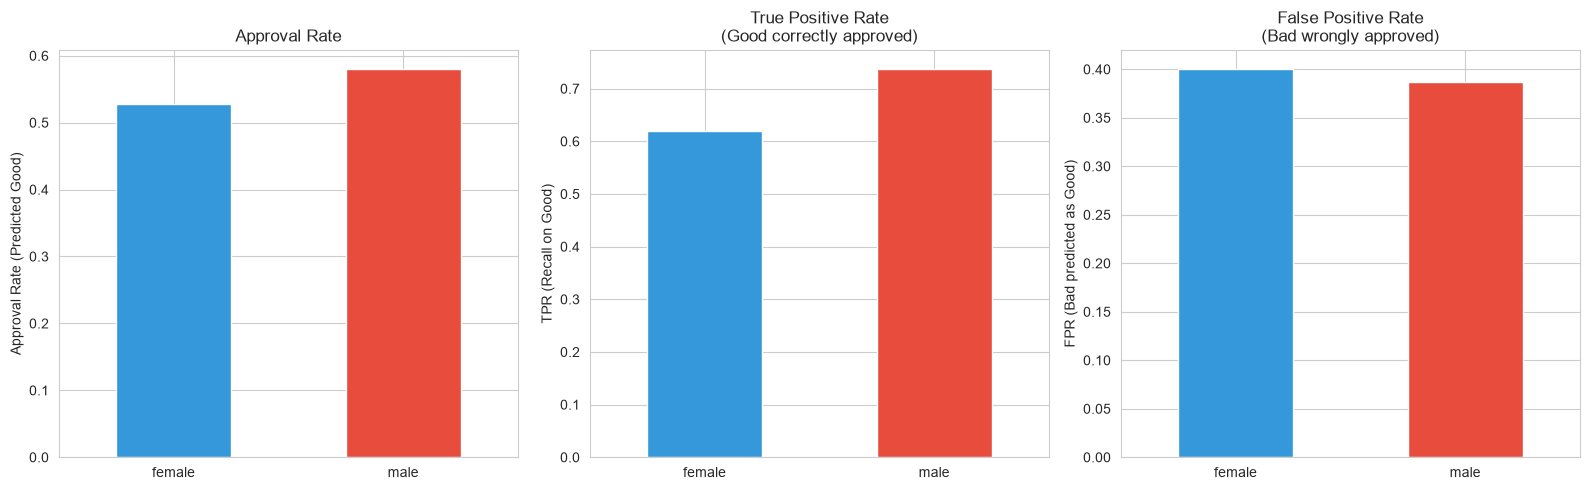

In [224]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ['Approval Rate (Predicted Good)', 'TPR (Recall on Good)', 'FPR (Bad predicted as Good)']
titles = ['Approval Rate', 'True Positive Rate\n(Good correctly approved)', 'False Positive Rate\n(Bad wrongly approved)']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    fairness_summary[metric].plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [225]:
# Retrain XGBoost WITHOUT the Sex feature to test if the fairness gap narrows
features_no_sex = [col for col in x_train.columns if col != 'Sex']

x_train_no_sex = x_train[features_no_sex]
x_test_no_sex = x_test[features_no_sex]

model_no_sex = xgb.XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=scale_pos_weight)
model_no_sex.fit(x_train_no_sex, y_train)

y_pred_no_sex = model_no_sex.predict(x_test_no_sex)
y_proba_no_sex = model_no_sex.predict_proba(x_test_no_sex)[:, 1]

# Re-run fairness analysis with the new predictions
fairness_df_no_sex = pd.DataFrame({
    'Sex': fairness_df['Sex'].values,  # we keep this only to GROUP BY, not as a model input
    'y_true': y_test.values,
    'y_pred': y_pred_no_sex,
    'y_proba': y_proba_no_sex
})

fairness_summary_no_sex = fairness_df_no_sex.groupby('Sex').apply(group_metrics)
print("=== Fairness Summary WITHOUT 'Sex' as a feature ===\n")
print(fairness_summary_no_sex)

male_row_ns = fairness_summary_no_sex.loc['male']
female_row_ns = fairness_summary_no_sex.loc['female']

eo_diff_ns = male_row_ns['TPR (Recall on Good)'] - female_row_ns['TPR (Recall on Good)']
di_ratio_ns = female_row_ns['Approval Rate (Predicted Good)'] / male_row_ns['Approval Rate (Predicted Good)']

print(f"\nEqual Opportunity Difference (no Sex feature): {eo_diff_ns:.3f}  (was {eo_diff:.3f} with Sex)")
print(f"Disparate Impact Ratio (no Sex feature): {di_ratio_ns:.3f}  (was {di_ratio:.3f} with Sex)")

# Also compare overall performance to check the fairness/accuracy tradeoff
f1_no_sex = f1_score(y_test, y_pred_no_sex, average='macro')
print(f"\nF1 (Macro) without Sex: {f1_no_sex:.3f}  (was {f1_score(y_test, y_pred_final, average='macro'):.3f} with Sex)")

=== Fairness Summary WITHOUT 'Sex' as a feature ===

        Count  Approval Rate (Predicted Good)  Actual Good Rate  Accuracy  \
Sex                                                                         
female   36.0                        0.527778          0.583333  0.555556   
male     69.0                        0.521739          0.550725  0.681159   

        TPR (Recall on Good)  FPR (Bad predicted as Good)  \
Sex                                                         
female              0.571429                     0.466667   
male                0.684211                     0.322581   

        TNR (Recall on Bad)  Avg Predicted Probability  
Sex                                                     
female             0.533333                   0.515334  
male               0.677419                   0.510419  

Equal Opportunity Difference (no Sex feature): 0.113  (was 0.118 with Sex)
Disparate Impact Ratio (no Sex feature): 1.012  (was 0.910 with Sex)

F1 (Macro) without 

In [226]:
sample_batch = df.drop(columns=['Risk', 'Unnamed: 0'], errors='ignore').sample(10, random_state=1)
sample_batch.to_csv('../data/sample_batch_applicants.csv', index=False)
print("Sample file created!")
sample_batch.head()

Sample file created!


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
187,23,male,2,own,little,moderate,882,13,radio/TV
335,44,male,2,own,little,little,1553,18,furniture/equipment
392,26,female,1,rent,moderate,moderate,4280,30,business
306,33,male,1,rent,little,moderate,2384,36,repairs
355,34,male,2,own,rich,moderate,3496,30,furniture/equipment


In [227]:
import joblib

model_filenames = {
    "Logistic Regression": "logistic_regression_balanced.pkl",
    "Random Forest": "random_forest_balanced.pkl",
    "Extra Trees": "extra_trees_balanced.pkl",
    "SVM": "svm_balanced.pkl",
    "XGBoost": "xgboost_balanced_credit_model.pkl"  # already saved, kept for consistency
}

for name, filename in model_filenames.items():
    model_obj = balanced_models[name]
    joblib.dump(model_obj, f"../models/{filename}")
    print(f"Saved {name} -> {filename}")

KeyError: 'Logistic Regression'

In [228]:
print(list(balanced_models.keys()))

['Logistic Regression (Balanced)', 'Random Forest (Balanced)', 'Extra Trees (Balanced)', 'SVM (Balanced)', 'XGBoost (Balanced)']


In [229]:
import joblib

model_filenames = {
    "Logistic Regression (Balanced)": "logistic_regression_balanced.pkl",
    "Random Forest (Balanced)": "random_forest_balanced.pkl",
    "Extra Trees (Balanced)": "extra_trees_balanced.pkl",
    "SVM (Balanced)": "svm_balanced.pkl",
    "XGBoost (Balanced)": "xgboost_balanced_credit_model.pkl"  # already saved, kept for consistency
}

for name, filename in model_filenames.items():
    model_obj = balanced_models[name]
    joblib.dump(model_obj, f"../models/{filename}")
    print(f"Saved {name} -> {filename}")

Saved Logistic Regression (Balanced) -> logistic_regression_balanced.pkl
Saved Random Forest (Balanced) -> random_forest_balanced.pkl
Saved Extra Trees (Balanced) -> extra_trees_balanced.pkl
Saved SVM (Balanced) -> svm_balanced.pkl
Saved XGBoost (Balanced) -> xgboost_balanced_credit_model.pkl
